# Diagnóstico y Análisis Integral de Datos: Train vs. Test y Evaluación de Imputación

**Objetivo:** Evaluar cuantitativa y visualmente:
1. La consistencia y distribución de las variables entre los conjuntos de **Train y Test** tras la partición estratificada.
2. El impacto y calidad del proceso de **imputación iterativa** (Pre vs. Post Imputación), evaluando la preservación de distribuciones, el llenado de nulos en productividad y el clipping de percentiles.
3. **Análisis multivariado adicional**: estabilidad de la matriz de correlaciones ($\Delta r$), proyección en componentes principales (PCA), test de Kolmogorov-Smirnov (KS-test) contra Covariate Shift y correspondencia con el desempeño del modelo registrado en el archivo `.pkl`.

In [1]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ==============================================================================
import os
import sys
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Configurar estilo visual profesional para publicaciones y reportes
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8
sns.set_theme(style="whitegrid", palette="muted")
print("[OK] Librerías importadas y entorno configurado correctamente.")

[OK] Librerías importadas y entorno configurado correctamente.


## 1. Configuración de Parámetros y Selección de Iteración
En esta celda se definen las rutas base del proyecto y se selecciona la **iteración** que se desea analizar:
- Si `SELECTED_ITERATION = None`, el notebook cargará automáticamente la **mejor iteración** registrada en `best_iterations_info.json` para el nutriente seleccionado.
- Si se asigna un entero (ej: `0`, `1`, `2`, `3`, `4`), se cargará y analizará esa iteración específica desde `historico_resultados.pkl`.
- Opcionalmente, `SAVE_FIGURES = True` exporta todas las figuras generadas en alta resolución (300 DPI) a una subcarpeta del directorio de resultados.

In [3]:
# ==============================================================================
# 2. CONFIGURACIÓN Y PARÁMETROS INTERACTIVOS
# ==============================================================================
from config import CFG
from new_utils import split_data_NPK, impute_data, renombrar_columnas, preparar_datos_NPK

# --- Parámetros de Selección ---
SELECTED_ITERATION = None  # None: usa la mejor iteración automáticamente; o especifica un entero (ej: 0, 1, 2, 3...)
SELECTED_ELEMENT = "Nitrogen"  # Opciones: 'Nitrogen', 'Phosphorus' o 'Potassium'
SAVE_FIGURES = False  # Guardar automáticamente figuras en formato PNG a 300 DPI

# Rutas a los archivos generados por el pipeline
path_historico = os.path.join(CFG.results_dir, "historico_resultados.pkl")
path_best = os.path.join(CFG.results_dir, "best_results.pkl")
path_info = os.path.join(CFG.results_dir, "best_iterations_info.json")

print(f"Directorio de resultados: {CFG.results_dir}")
print(f"Base de datos limpia: {CFG.data_path_clean}")

Directorio de resultados: D:\Estudio\OneDrive - Universidad de Antioquia\Estudio\PAI\Codigo\Code_Quindio\Analisis-PAI/Resultados/pipeline_imputation_NPK
Base de datos limpia: D:\Estudio\OneDrive - Universidad de Antioquia\Estudio\PAI\Codigo\Code_Quindio\Analisis-PAI/BaseDatos/BD Quindio unificados V2/df_filtered.csv


## 2. Carga de los archivos PKL y reconstrucción limitada de datos
Cargamos `historico_resultados.pkl`, `best_results.pkl` y `best_iterations_info.json`.

Cada resultado de modelo guarda directamente:
- `X_test`, `y_test` y `feature_names`: los datos de evaluación ya preparados para el modelo.
- `grid_search`: el `GridSearchCV` completo, incluido el `best_estimator_` y su pipeline de escalado/clasificación.
- Métricas, predicciones, reporte de clasificación y matriz de confusión.

El PKL **no guarda `X_train` ni los DataFrames completos antes/después de imputar**. Por eso, el notebook reconstruye de forma reproducible la partición y la imputación únicamente para analizar Train, valores faltantes y transformaciones. Para Test, las variables predictoras y la variable objetivo se toman directamente de `X_test` y `y_test` del PKL.

In [5]:
# ==============================================================================
# 3. CARGA DE RESULTADOS PKL Y RECONSTRUCCIÓN LIMITADA DE DATOS
# ==============================================================================
# Cargar metadatos de las mejores iteraciones
with open(path_info, 'r', encoding='utf-8') as f:
    best_info = json.load(f)

print("--- Metadatos de Mejores Iteraciones Registradas por Elemento ---")
for elem, info in best_info.items():
    iter_val = info.get('mejor_iteracion', info.get('iteracion', 0))
    score_val = info.get('f1_test_macro_promedio', 0)
    print(f"  Elemento: {elem:<12} | Ganadora: Iteración {iter_val + 1} (idx={iter_val}) | F1-Macro Promedio: {score_val:.4f}")

# El histórico permite analizar cualquier iteración; best_results contiene solo las ganadoras.
with open(path_historico, 'rb') as f:
    historico_resultados = pickle.load(f)
with open(path_best, 'rb') as f:
    best_results = pickle.load(f)

# Determinar el índice de iteración a evaluar
if SELECTED_ITERATION is None:
    iter_idx = best_info[SELECTED_ELEMENT].get('mejor_iteracion', best_info[SELECTED_ELEMENT].get('iteracion', 0))
    print(f"\n[INFO] Modo Automático: Analizando la mejor iteración para {SELECTED_ELEMENT} -> Iteración {iter_idx + 1} (idx={iter_idx})")
else:
    iter_idx = int(SELECTED_ITERATION)
    print(f"\n[INFO] Modo Manual: Analizando la iteración especificada -> Iteración {iter_idx + 1} (idx={iter_idx})")

current_seed = CFG.base_seed + iter_idx
print(f"[INFO] Semilla reproducible asociada: {current_seed}")

# Extraer un resultado completo del PKL para el elemento e iteración seleccionados.
model_names = list(historico_resultados[SELECTED_ELEMENT][iter_idx].keys())
sample_model = model_names[0]
pkl_result = historico_resultados[SELECTED_ELEMENT][iter_idx][sample_model]

feature_names = pkl_result['feature_names']
X_test_pkl = pkl_result['X_test'].copy()
y_test_pkl = pd.Series(pkl_result['y_test'], index=X_test_pkl.index, name=SELECTED_ELEMENT)
grid_search_pkl = pkl_result['grid_search']
pipeline_pkl = grid_search_pkl.best_estimator_

# La partición/imputación se reconstruye solo para obtener la vista pre-imputación
# y el conjunto Train, que no fueron serializados dentro del resultado del modelo.
data_clean = pd.read_csv(CFG.data_path_clean)
train_raw, test_raw = split_data_NPK(
    data_clean,
    test_size=CFG.test_size,
    random_state=current_seed
)
train_raw_renamed = renombrar_columnas(train_raw)
test_raw_renamed = renombrar_columnas(test_raw)
train_imputed, test_imputed_reconstructed = impute_data(
    train_raw,
    test_raw,
    seed=current_seed
)

# Test post-imputación: las predictoras y la etiqueta provienen directamente del PKL.
# Se conservan en el DataFrame reconstruido las columnas auxiliares para las auditorías.
test_imputed = test_imputed_reconstructed.copy()
test_imputed.loc[X_test_pkl.index, feature_names] = X_test_pkl[feature_names]
test_imputed.loc[y_test_pkl.index, SELECTED_ELEMENT] = y_test_pkl

# Validación de que el pipeline y los datos del PKL reproducen las predicciones guardadas.
y_pred_from_pipeline = pipeline_pkl.predict(X_test_pkl)
predictions_match = np.array_equal(np.asarray(y_pred_from_pipeline), np.asarray(pkl_result['y_pred']))

print(f"\n[PKL] Modelo de referencia: {sample_model}")
print(f"[PKL] GridSearchCV cargado: {type(grid_search_pkl).__name__}")
print(f"[PKL] Pipeline cargado: {pipeline_pkl}")
print(f"[PKL] X_test: {X_test_pkl.shape} | y_test: {y_test_pkl.shape}")
print(f"[VALIDACIÓN] Predicciones del pipeline = predicciones guardadas: {predictions_match}")
print(f"[VALIDACIÓN] Filas Train reconstruido: {len(train_imputed)} | Filas Test: {len(test_imputed)}")
print(f"[VALIDACIÓN] Total de características predictoras ({len(feature_names)}): {feature_names}")

if not predictions_match:
    raise ValueError("Las predicciones del pipeline cargado no coinciden con las predicciones guardadas en el PKL.")

# Directorio de exportación de gráficos
if SAVE_FIGURES:
    fig_dir = os.path.join(CFG.results_dir, f"eda_visualizations_iter_{iter_idx + 1}_{SELECTED_ELEMENT}")
    os.makedirs(fig_dir, exist_ok=True)
    print(f"[INFO] Exportación activa. Figuras se guardarán en: {fig_dir}")

--- Metadatos de Mejores Iteraciones Registradas por Elemento ---
  Elemento: Nitrogen     | Ganadora: Iteración 2 (idx=1) | F1-Macro Promedio: 0.8125
  Elemento: Phosphorus   | Ganadora: Iteración 2 (idx=1) | F1-Macro Promedio: 0.7987
  Elemento: Potassium    | Ganadora: Iteración 2 (idx=1) | F1-Macro Promedio: 0.8315

[INFO] Modo Automático: Analizando la mejor iteración para Nitrogen -> Iteración 2 (idx=1)
[INFO] Semilla reproducible asociada: 43

[PKL] Modelo de referencia: RF
[PKL] GridSearchCV cargado: GridSearchCV
[PKL] Pipeline cargado: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(max_depth=10, n_estimators=50,
                                        random_state=42))])
[PKL] X_test: (679, 26) | y_test: (679,)
[VALIDACIÓN] Predicciones del pipeline = predicciones guardadas: True
[VALIDACIÓN] Filas Train reconstruido: 1583 | Filas Test: 679
[VALIDACIÓN] Total de características predictoras (26): ['Plant_Height (cm)

## 3. Análisis 1: Diagnóstico de Valores Faltantes (Pre-Imputación)
Examinamos el porcentaje y conteo de valores nulos por variable en los conjuntos de `Train` y `Test` antes de la imputación.  
Esto nos permite auditar qué variables requerían intervención estocástica (`IterativeImputer`) y cuáles pertenecen al grupo de productividad (`fillna(0)`).

--- Resumen de Variables con Valores Faltantes (Pre-Imputación) ---


,Variable,% Nulos Train,% Nulos Test,Conteo Nulos Train,Conteo Nulos Test
0,Plant_Height (cm),84.902085,85.714286,1344,582
1,Sap Ca (ppm),79.974732,79.970545,1266,543
2,Number of Flowers,79.343020,78.497791,1256,533
3,Soil Ca Horiba (ppm),79.279848,78.203240,1255,531
4,Sap pH,78.521794,79.086892,1243,537
5,Sap Na (ppm),78.458623,79.086892,1242,537
6,Sap NO3 (ppm),78.458623,79.086892,1242,537
7,Sap Conductivity (mS/cm),78.458623,79.086892,1242,537
8,Sap K (ppm),78.458623,79.086892,1242,537
9,Soil NO3 Horiba (ppm),75.173721,74.668630,1190,507


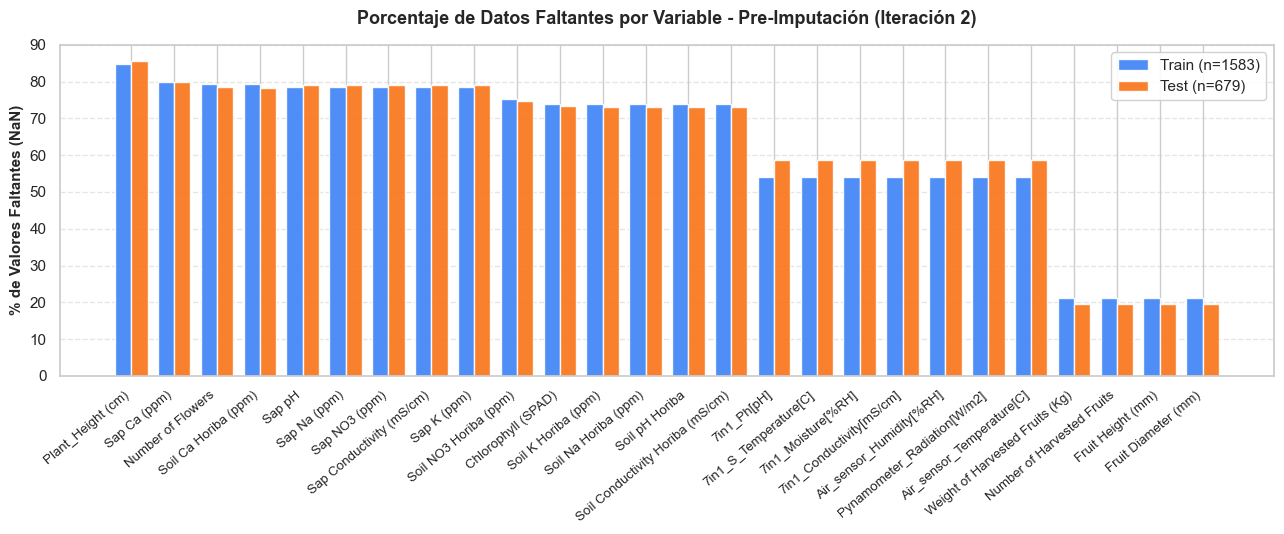

In [6]:
# ==============================================================================
# 4. AUDITORÍA DE DATOS FALTANTES (PRE-IMPUTACIÓN)
# ==============================================================================
# Calcular % de nulos por variable en Train y Test
null_train = train_raw_renamed[feature_names].isna().mean() * 100
null_test = test_raw_renamed[feature_names].isna().mean() * 100

df_missing = pd.DataFrame({
    'Variable': feature_names,
    '% Nulos Train': null_train.values,
    '% Nulos Test': null_test.values,
    'Conteo Nulos Train': train_raw_renamed[feature_names].isna().sum().values,
    'Conteo Nulos Test': test_raw_renamed[feature_names].isna().sum().values
}).sort_values(by='% Nulos Train', ascending=False).reset_index(drop=True)

# Filtrar variables que efectivamente tienen datos faltantes
df_missing_active = df_missing[df_missing['% Nulos Train'] > 0]

print("--- Resumen de Variables con Valores Faltantes (Pre-Imputación) ---")
display(df_missing_active)

# Gráfico de barras de porcentaje de nulos
plt.figure(figsize=(13, 5.5))
x_indices = np.arange(len(df_missing_active))
bar_width = 0.38

plt.bar(x_indices - bar_width/2, df_missing_active['% Nulos Train'], width=bar_width, 
        label=f'Train (n={len(train_raw_renamed)})', color='#3b82f6', alpha=0.9)
plt.bar(x_indices + bar_width/2, df_missing_active['% Nulos Test'], width=bar_width, 
        label=f'Test (n={len(test_raw_renamed)})', color='#f97316', alpha=0.9)

plt.xticks(x_indices, df_missing_active['Variable'], rotation=40, ha='right', fontsize=9.5)
plt.ylabel('% de Valores Faltantes (NaN)', fontsize=11, fontweight='bold')
plt.title(f'Porcentaje de Datos Faltantes por Variable - Pre-Imputación (Iteración {iter_idx + 1})', fontsize=13, fontweight='bold', pad=15)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(os.path.join(fig_dir, "01_porcentaje_datos_faltantes_pre_imputacion.png"), dpi=300)
plt.show()

## 4. Análisis 2: Comparación Antes vs. Después de la Imputación (Pre vs. Post Imputation)
Evaluamos en profundidad el impacto del algoritmo de imputación:
1. **Densidad y Distribución (KDEs Superpuestos)**: Para cada variable imputada por Random Forest, comparamos:
   - **Originales (Observados)**: Registros no nulos originales.
   - **Solo Imputados (Sintéticos)**: Únicamente los registros generados por el modelo de imputación.
   - **Total Post-Imputación**: La variable final resultante.
2. **Boxplots Comparativos Pre vs. Post**: Evaluación del desplazamiento de medianas, dispersión y rangos intercuartílicos.
3. **Auditoría de Productividad (Llenado con 0)**: Verificación del comportamiento de flores, frutos cosechados y peso tras aplicar la regla de negocio.
4. **Auditoría de Clipping (Percentiles 1% y 99%)**: Conteo exacto de outliers acotados por los límites de corte.

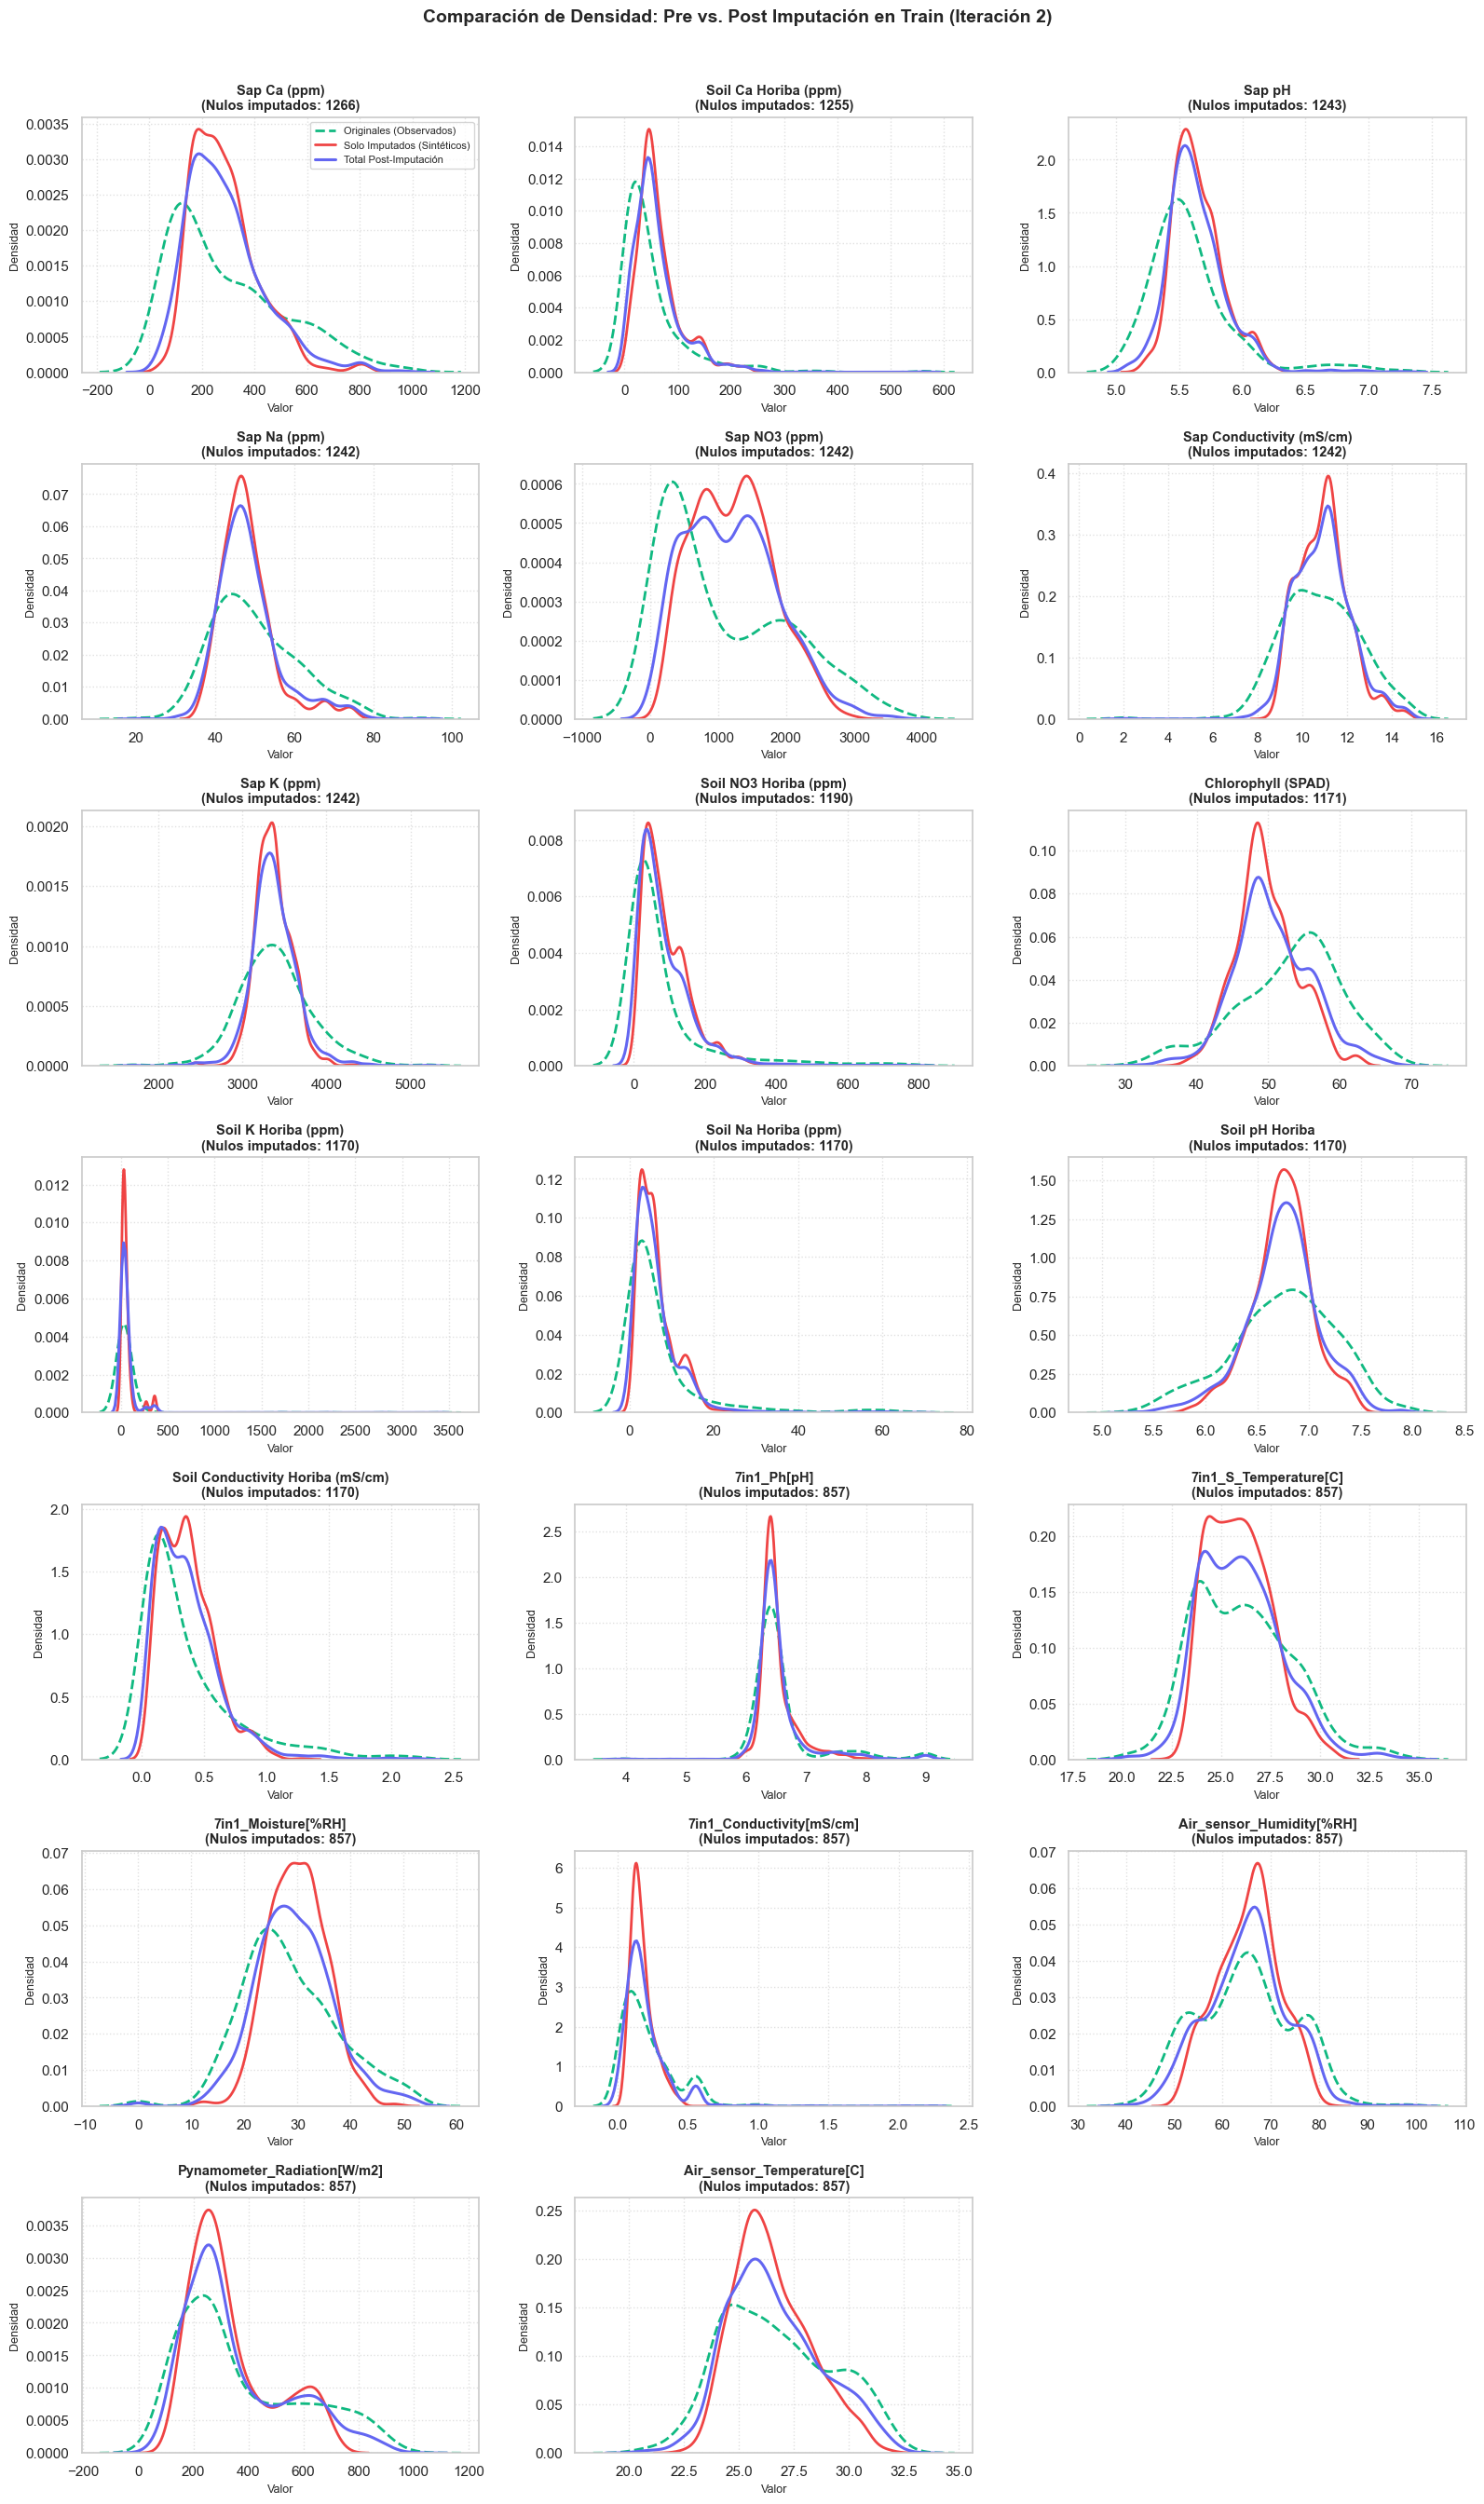

In [7]:
# ==============================================================================
# 5. COMPARACIÓN DE DENSIDADES (KDE): ORIGINAL vs. IMPUTADO vs. TOTAL POST
# ==============================================================================
# Variables imputadas con IterativeImputer (excluyendo las de productividad con fillna=0)
vars_imputed_rf = [col for col in df_missing_active['Variable'] if col not in CFG.productivity_vars and col in feature_names]

n_vars = len(vars_imputed_rf)
ncols = 3
nrows = int(np.ceil(n_vars / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.8 * nrows))
axes = axes.flatten()

for i, col in enumerate(vars_imputed_rf):
    ax = axes[i]
    
    # Valores de Train
    orig_vals = train_raw_renamed[col].dropna()
    mask_was_nan = train_raw_renamed[col].isna()
    imputed_only_vals = train_imputed.loc[mask_was_nan, col]
    post_vals = train_imputed[col]
    
    # Superposición de densidades KDE
    if len(orig_vals) > 1:
        sns.kdeplot(orig_vals, ax=ax, label='Originales (Observados)', color='#10b981', linewidth=2, linestyle='--')
    if len(imputed_only_vals) > 1:
        sns.kdeplot(imputed_only_vals, ax=ax, label='Solo Imputados (Sintéticos)', color='#ef4444', linewidth=2)
    sns.kdeplot(post_vals, ax=ax, label='Total Post-Imputación', color='#6366f1', linewidth=2.2)
    
    ax.set_title(f"{col}\n(Nulos imputados: {mask_was_nan.sum()})", fontsize=10.5, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=9)
    ax.set_ylabel('Densidad', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)
    if i == 0:
        ax.legend(fontsize=8, loc='upper right')

# Eliminar ejes vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"Comparación de Densidad: Pre vs. Post Imputación en Train (Iteración {iter_idx + 1})", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(os.path.join(fig_dir, "02_kde_pre_vs_post_imputacion_variables_clave.png"), dpi=300, bbox_inches='tight')
plt.show()

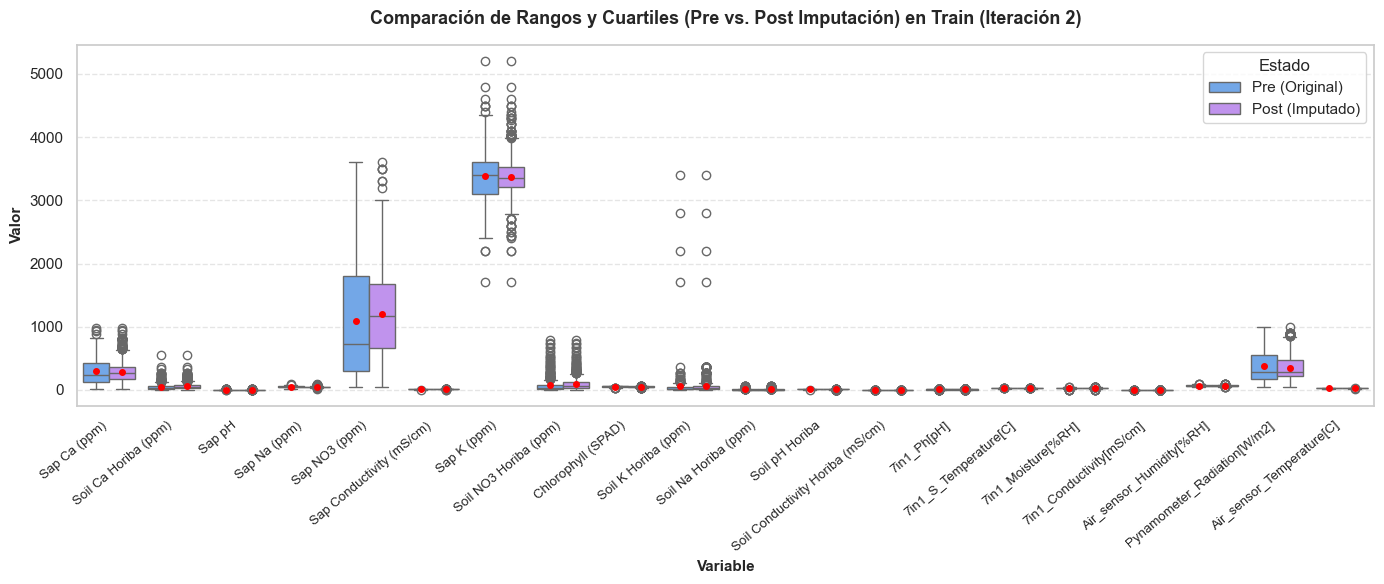

In [8]:
# ==============================================================================
# 6. BOXPLOTS PRE vs. POST IMPUTACIÓN (DISPERSIÓN Y MEDIANAS)
# ==============================================================================
pre_post_records = []
for col in vars_imputed_rf:
    for v in train_raw_renamed[col].dropna():
        pre_post_records.append({'Variable': col, 'Valor': v, 'Estado': 'Pre (Original)'})
    for v in train_imputed[col]:
        pre_post_records.append({'Variable': col, 'Valor': v, 'Estado': 'Post (Imputado)'})

df_pre_post_box = pd.DataFrame(pre_post_records)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_pre_post_box, x='Variable', y='Valor', hue='Estado', 
            palette={'Pre (Original)': '#60a5fa', 'Post (Imputado)': '#c084fc'}, 
            showmeans=True, meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"red", "markersize":4})

plt.xticks(rotation=40, ha='right', fontsize=9.5)
plt.title(f"Comparación de Rangos y Cuartiles (Pre vs. Post Imputación) en Train (Iteración {iter_idx + 1})", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Variable", fontsize=11, fontweight='bold')
plt.ylabel("Valor", fontsize=11, fontweight='bold')
plt.legend(title="Estado", frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(os.path.join(fig_dir, "03_boxplots_pre_vs_post_imputacion.png"), dpi=300)
plt.show()

In [9]:
# ==============================================================================
# 7. AUDITORÍA DE PRODUCTIVIDAD (FILLNA=0) Y CLIPPING (PERCENTILES 1% Y 99%)
# ==============================================================================
print("=== 1. AUDITORÍA DE VARIABLES DE PRODUCTIVIDAD (REGLA FILLNA = 0) ===")
prod_cols_present = [c for c in CFG.productivity_vars if c in train_raw_renamed.columns]
prod_summary = []
for c in prod_cols_present:
    nulos_tr = train_raw_renamed[c].isna().sum()
    ceros_post_tr = (train_imputed[c] == 0).sum()
    nulos_te = test_raw_renamed[c].isna().sum()
    ceros_post_te = (test_imputed[c] == 0).sum()
    prod_summary.append({
        'Variable': c,
        'Nulos Pre (Train)': nulos_tr,
        'Ceros Post (Train)': ceros_post_tr,
        'Nulos Pre (Test)': nulos_te,
        'Ceros Post (Test)': ceros_post_te
    })
display(pd.DataFrame(prod_summary))

print("\n=== 2. AUDITORÍA DEL EFECTO DE CLIPPING (LIMITES P1 Y P99 DE TRAIN) ===")
limites = train_raw_renamed.select_dtypes(include=[float, int]).quantile([0.01, 0.99]).T
limites.columns = ['min_val', 'max_val']

clipping_report = []
for col in vars_imputed_rf:
    if col in limites.index:
        min_v, max_v = limites.loc[col, 'min_val'], limites.loc[col, 'max_val']
        # En Train (solo registros que originalmente eran NaN)
        mask_nan_tr = train_raw_renamed[col].isna()
        clipped_tr = ((train_imputed.loc[mask_nan_tr, col] <= min_v) | (train_imputed.loc[mask_nan_tr, col] >= max_v)).sum()
        
        # En Test (solo registros que originalmente eran NaN)
        mask_nan_te = test_raw_renamed[col].isna()
        clipped_te = ((test_imputed.loc[mask_nan_te, col] <= min_v) | (test_imputed.loc[mask_nan_te, col] >= max_v)).sum()
        
        clipping_report.append({
            'Variable': col,
            'Límite Inferior (P1)': round(min_v, 3),
            'Límite Superior (P99)': round(max_v, 3),
            'Outliers Acotados en Train': clipped_tr,
            'Outliers Acotados en Test': clipped_te
        })
display(pd.DataFrame(clipping_report))

=== 1. AUDITORÍA DE VARIABLES DE PRODUCTIVIDAD (REGLA FILLNA = 0) ===


,Variable,Nulos Pre (Train),Ceros Post (Train),Nulos Pre (Test),Ceros Post (Test)
0,Plant_Height (cm),1344,0,582,0
1,Number of Flowers,1256,1266,533,535
2,Number of Harvested Fruits,335,578,132,226
3,Weight of Harvested Fruits (Kg),335,577,132,226
4,Fruit Height (mm),335,577,132,226
5,Fruit Diameter (mm),335,577,132,226



=== 2. AUDITORÍA DEL EFECTO DE CLIPPING (LIMITES P1 Y P99 DE TRAIN) ===


,Variable,Límite Inferior (P1),Límite Superior (P99),Outliers Acotados en Train,Outliers Acotados en Test
0,Sap Ca (ppm),34.640,878.800,0,0
1,Soil Ca Horiba (ppm),4.000,263.650,0,0
2,Sap pH,5.100,6.961,0,0
3,Sap Na (ppm),31.400,77.600,0,0
4,Sap NO3 (ppm),53.200,3420.000,0,0
5,Sap Conductivity (mS/cm),7.362,14.632,1,0
6,Sap K (ppm),2440.000,4500.000,4,0
7,Soil NO3 Horiba (ppm),1.000,666.720,0,0
8,Chlorophyll (SPAD),34.855,66.489,0,0
9,Soil K Horiba (ppm),0.500,358.000,39,15


## 5. Análisis 3: Comparación y Distribución Train vs. Test (Post-Imputación)
Evaluamos la representatividad y balance de la partición:
1. **Balance de Tratamientos Estratificados NPK**: Comprobamos si la proporción de cada combinación de tratamiento (`N0P0K0`, `N1P2K1`, etc.) se mantuvo idéntica en Train y Test.
2. **Balance de Clases Objetivo**: Distribución de las clases del nutriente objetivo (`Nitrogen`, `Phosphorus`, `Potassium`).
3. **Grid de Densidad KDE (Train vs. Test)**: Comparación visual de todas las características predictoras en ambos conjuntos.
4. **Test de Kolmogorov-Smirnov (KS-Test)**: Diagnóstico estadístico riguroso de 2 muestras contra *Covariate Shift*. Un $p \text{-valor} > 0.05$ garantiza que Train y Test provienen de la misma distribución.

--- Verificación de Estratificación NPK (Top 10 Tratamientos) ---


,% Train,% Test,Diferencia Absoluta (%)
0,,,
N0P0K0,6.569804,6.627393,0.057589
N0P0K1,3.221731,3.240059,0.018328
N0P0K2,3.348073,3.387334,0.039261
N0P1K0,3.284902,3.387334,0.102432
N0P1K1,3.284902,3.387334,0.102432
N0P1K2,3.411244,3.387334,0.023910
N0P2K0,3.348073,3.240059,0.108014
N0P2K1,3.284902,3.387334,0.102432
N0P2K2,3.348073,3.387334,0.039261


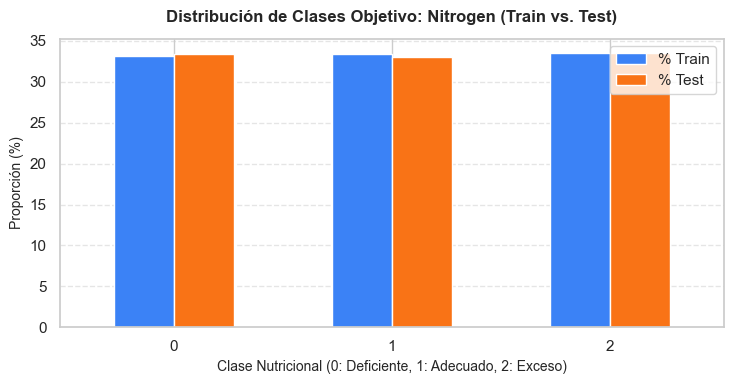

In [10]:
# ==============================================================================
# 8. VALIDACIÓN DE ESTRATIFICACIÓN NPK Y BALANCE DE CLASES
# ==============================================================================
# Balance de tratamientos NPK
train_tr_dist = train_raw['Tratamiento'].str.extract(r'(N\dP\dK\d)')[0].value_counts(normalize=True) * 100
test_tr_dist = test_raw['Tratamiento'].str.extract(r'(N\dP\dK\d)')[0].value_counts(normalize=True) * 100

df_npk_strat = pd.DataFrame({'% Train': train_tr_dist, '% Test': test_tr_dist}).fillna(0)
df_npk_strat['Diferencia Absoluta (%)'] = (df_npk_strat['% Train'] - df_npk_strat['% Test']).abs()

print("--- Verificación de Estratificación NPK (Top 10 Tratamientos) ---")
display(df_npk_strat.head(10))

# Balance de Clases del Nutriente Seleccionado
target_train_dist = train_imputed[SELECTED_ELEMENT].value_counts(normalize=True) * 100
target_test_dist = test_imputed[SELECTED_ELEMENT].value_counts(normalize=True) * 100
df_target_bal = pd.DataFrame({'% Train': target_train_dist, '% Test': target_test_dist})

plt.figure(figsize=(7.5, 4))
df_target_bal.plot(kind='bar', color=['#3b82f6', '#f97316'], ax=plt.gca(), width=0.55)
plt.title(f"Distribución de Clases Objetivo: {SELECTED_ELEMENT} (Train vs. Test)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Clase Nutricional (0: Deficiente, 1: Adecuado, 2: Exceso)", fontsize=10)
plt.ylabel("Proporción (%)", fontsize=10)
plt.xticks(rotation=0)
plt.legend(frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(os.path.join(fig_dir, "04_balance_clases_target_train_test.png"), dpi=300)
plt.show()

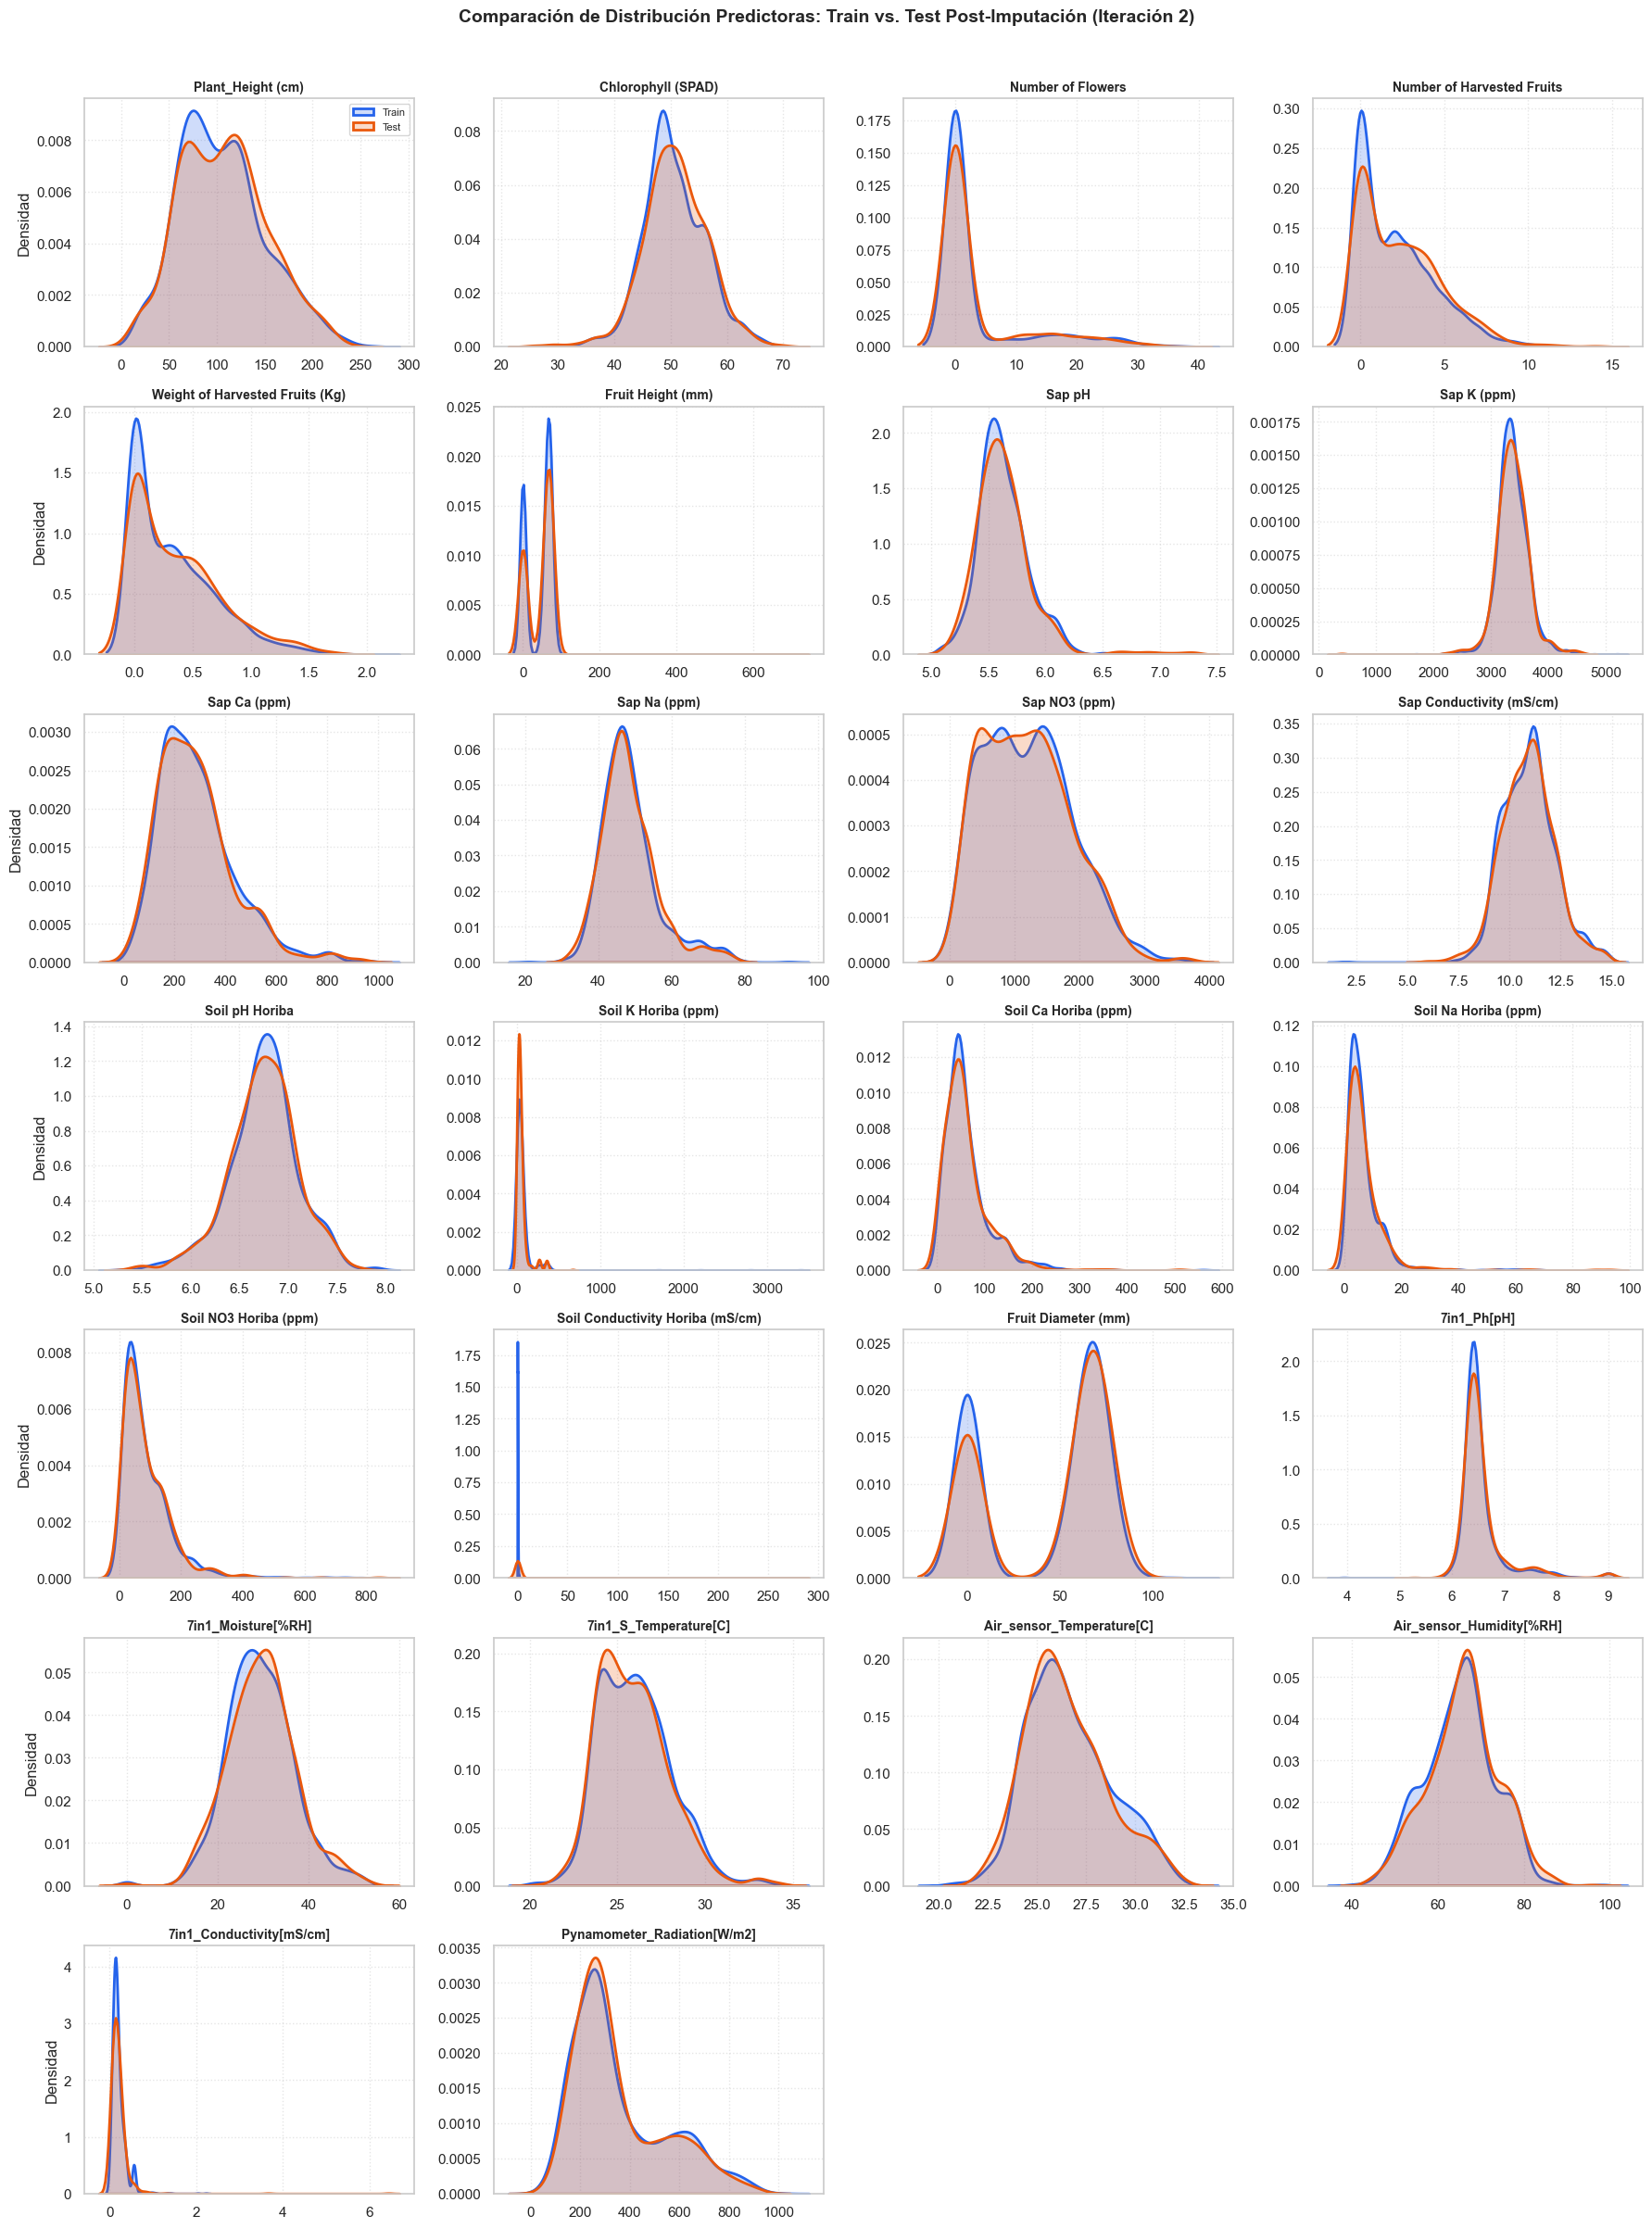

In [11]:
# ==============================================================================
# 9. GRID DE DISTRIBUCIÓN TRAIN vs. TEST (POST-IMPUTACIÓN)
# ==============================================================================
n_feats = len(feature_names)
ncols = 4
nrows = int(np.ceil(n_feats / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.4 * nrows))
axes = axes.flatten()

for i, col in enumerate(feature_names):
    ax = axes[i]
    sns.kdeplot(train_imputed[col], ax=ax, label='Train', color='#2563eb', fill=True, alpha=0.22, linewidth=2)
    sns.kdeplot(test_imputed[col], ax=ax, label='Test', color='#ea580c', fill=True, alpha=0.22, linewidth=2)
    
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Densidad' if i % ncols == 0 else '')
    ax.grid(True, linestyle=':', alpha=0.5)
    if i == 0:
        ax.legend(fontsize=8, loc='upper right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"Comparación de Distribución Predictoras: Train vs. Test Post-Imputación (Iteración {iter_idx + 1})", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(os.path.join(fig_dir, "05_distribucion_train_vs_test_post_imputacion.png"), dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# ==============================================================================
# 10. TEST ESTADÍSTICO DE COVARIATE SHIFT (KOLMOGOROV-SMIRNOV)
# ==============================================================================
ks_results = []
for col in feature_names:
    stat, p_val = stats.ks_2samp(train_imputed[col], test_imputed[col])
    w_dist = stats.wasserstein_distance(train_imputed[col], test_imputed[col])
    ks_results.append({
        'Variable': col,
        'Estadístico KS': round(stat, 4),
        'p-valor KS': round(p_val, 4),
        'Distancia Wasserstein': round(w_dist, 4),
        'Diagnóstico (α=0.05)': 'Misma Distribución (p > 0.05)' if p_val >= 0.05 else 'Alerta Shift (p < 0.05)'
    })

df_ks = pd.DataFrame(ks_results).sort_values(by='p-valor KS').reset_index(drop=True)
print("--- Test Kolmogorov-Smirnov de 2 Muestras (Train vs. Test) ---")
display(df_ks)

alertas = (df_ks['p-valor KS'] < 0.05).sum()
if alertas == 0:
    print("\n[CONCLUSIÓN KS] EXCELENTE: Ninguna variable muestra Covariate Shift estadísticamente significativo (todos p > 0.05).")
else:
    print(f"\n[ALERTA KS] Existen {alertas} variables con p < 0.05 que requieren atención en generalización.")

--- Test Kolmogorov-Smirnov de 2 Muestras (Train vs. Test) ---


,Variable,Estadístico KS,p-valor KS,Distancia Wasserstein,Diagnóstico (α=0.05)
0,Weight of Harvested Fruits (Kg),0.0671,0.0263,0.0396,Alerta Shift (p < 0.05)
1,Chlorophyll (SPAD),0.0640,0.0388,0.4153,Alerta Shift (p < 0.05)
2,Number of Harvested Fruits,0.0578,0.0800,0.2694,Misma Distribución (p > 0.05)
3,7in1_Conductivity[mS/cm],0.0577,0.0805,0.0249,Misma Distribución (p > 0.05)
4,Plant_Height (cm),0.0560,0.0972,2.9137,Misma Distribución (p > 0.05)
5,Air_sensor_Humidity[%RH],0.0555,0.1021,0.8949,Misma Distribución (p > 0.05)
6,Fruit Diameter (mm),0.0494,0.1892,2.6184,Misma Distribución (p > 0.05)
7,7in1_Moisture[%RH],0.0484,0.2073,0.4707,Misma Distribución (p > 0.05)
8,7in1_S_Temperature[C],0.0468,0.2392,0.1602,Misma Distribución (p > 0.05)
9,Air_sensor_Temperature[C],0.0458,0.2626,0.1810,Misma Distribución (p > 0.05)



[ALERTA KS] Existen 2 variables con p < 0.05 que requieren atención en generalización.


## 6. Análisis Adicional 1: Estabilidad de Correlaciones Multivariadas
Un riesgo habitual de la imputación multivariada es distorsionar las relaciones físico-químicas del suelo y la planta.  
En esta sección comparamos:
1. Matriz de correlación de Pearson Pre-imputación ($R_{pre}$).
2. Matriz de correlación Post-imputación ($R_{post}$).
3. **Matriz de diferencia absoluta** $|\Delta R| = |R_{post} - R_{pre}|$. Un valor bajo confirma que la covarianza multivariada se preservó de forma fidedigna.

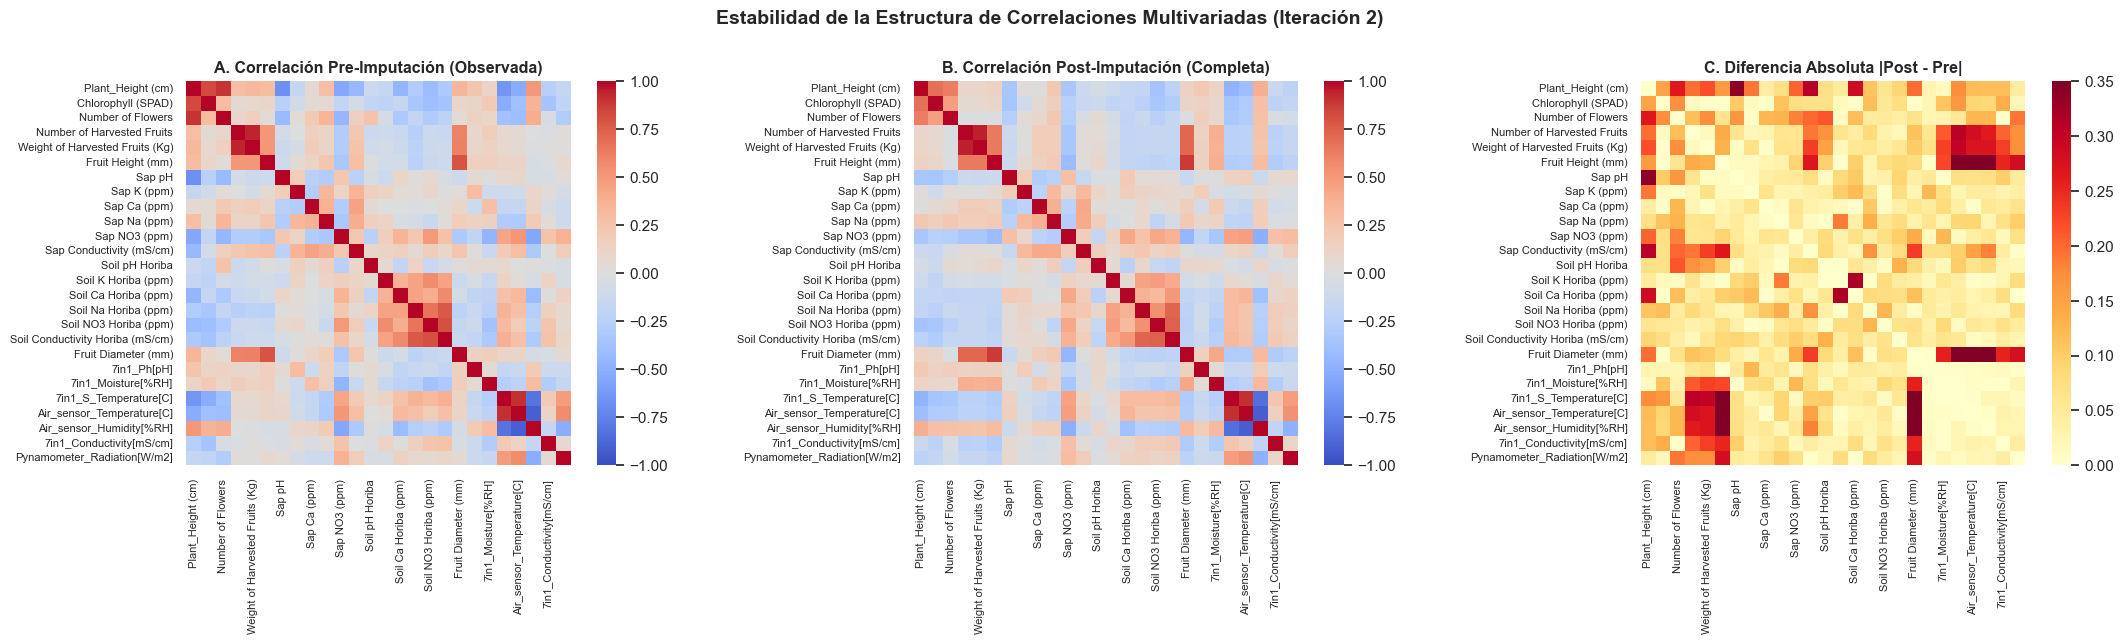

[ESTADÍSTICA] Diferencia de correlación promedio: 0.0797
[ESTADÍSTICA] Máxima distorsión puntual detectada: 0.4141


In [13]:
# ==============================================================================
# 11. MATRIZ DE CORRELACIONES PRE vs. POST Y DIFERENCIA ABSOLUTA
# ==============================================================================
cols_corr = [c for c in feature_names if c not in ['Treatment_Num', 'Year', 'Month', 'Day']]

# Correlación Pre (pairwise complete)
corr_pre = train_raw_renamed[cols_corr].corr()

# Correlación Post
corr_post = train_imputed[cols_corr].corr()

# Matriz de Diferencia
corr_diff = (corr_post - corr_pre).abs()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# A. Pre
sns.heatmap(corr_pre, ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1, cbar=True, square=True)
axes[0].set_title("A. Correlación Pre-Imputación (Observada)", fontsize=11.5, fontweight='bold')

# B. Post
sns.heatmap(corr_post, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1, cbar=True, square=True)
axes[1].set_title("B. Correlación Post-Imputación (Completa)", fontsize=11.5, fontweight='bold')

# C. Diferencia
sns.heatmap(corr_diff, ax=axes[2], cmap='YlOrRd', vmin=0, vmax=0.35, cbar=True, square=True)
axes[2].set_title("C. Diferencia Absoluta |Post - Pre|", fontsize=11.5, fontweight='bold')

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=8)

plt.suptitle(f"Estabilidad de la Estructura de Correlaciones Multivariadas (Iteración {iter_idx + 1})", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(os.path.join(fig_dir, "06_estabilidad_correlaciones_pre_post.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"[ESTADÍSTICA] Diferencia de correlación promedio: {corr_diff.mean().mean():.4f}")
print(f"[ESTADÍSTICA] Máxima distorsión puntual detectada: {corr_diff.max().max():.4f}")

## 7. Análisis Adicional 2: Proyección Multivariada en Espacio Latente (PCA)
Reducimos la dimensionalidad mediante Análisis de Componentes Principales (PCA) sobre las características predictoras escaladas:
1. **Proyección 2D Train vs. Test**: Para verificar si ambos subconjuntos ocupan el mismo hipervolumen en el espacio latente.
2. **Separación de Clases**: Proyección coloreada por los niveles nutricionales del nutriente evaluado (`Deficiencia`, `Adecuado`, `Exceso`).

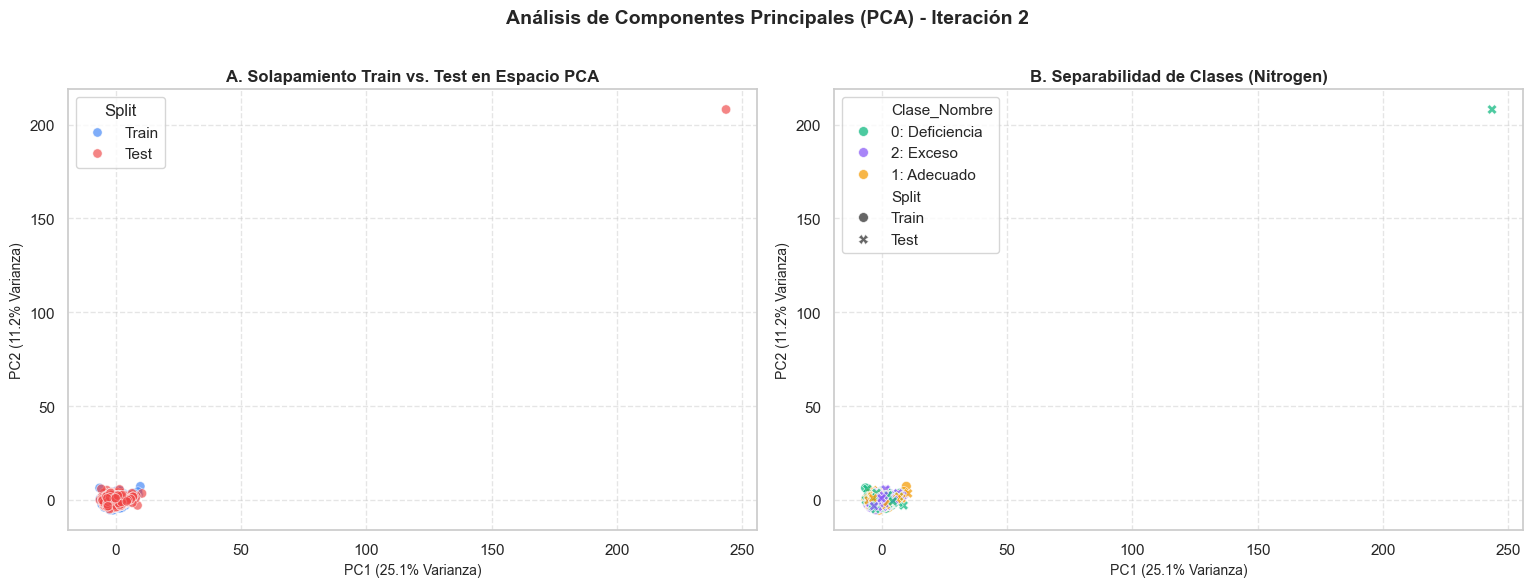

In [14]:
# ==============================================================================
# 12. PROYECCIÓN MULTIVARIADA PCA (TRAIN vs. TEST Y CLASES)
# ==============================================================================
# Estandarización ajustada solo en Train
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(train_imputed[feature_names])
X_te_scaled = scaler.transform(test_imputed[feature_names])

pca = PCA(n_components=2, random_state=42)
X_tr_pca = pca.fit_transform(X_tr_scaled)
X_te_pca = pca.transform(X_te_scaled)

var_exp = pca.explained_variance_ratio_ * 100

df_pca = pd.DataFrame({
    'PC1': np.concatenate([X_tr_pca[:, 0], X_te_pca[:, 0]]),
    'PC2': np.concatenate([X_tr_pca[:, 1], X_te_pca[:, 1]]),
    'Split': ['Train'] * len(X_tr_pca) + ['Test'] * len(X_te_pca),
    'Clase': np.concatenate([train_imputed[SELECTED_ELEMENT].values, test_imputed[SELECTED_ELEMENT].values])
})

class_names = {0: '0: Deficiencia', 1: '1: Adecuado', 2: '2: Exceso'}
df_pca['Clase_Nombre'] = df_pca['Clase'].map(class_names)

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8))

# 1. Train vs Test
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Split', palette={'Train': '#3b82f6', 'Test': '#ef4444'}, 
                alpha=0.65, s=45, ax=axes[0])
axes[0].set_title(f"A. Solapamiento Train vs. Test en Espacio PCA", fontsize=12, fontweight='bold')
axes[0].set_xlabel(f"PC1 ({var_exp[0]:.1f}% Varianza)", fontsize=10)
axes[0].set_ylabel(f"PC2 ({var_exp[1]:.1f}% Varianza)", fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Clases Nutricionales
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Clase_Nombre', 
                palette={'0: Deficiencia': '#10b981', '1: Adecuado': '#f59e0b', '2: Exceso': '#8b5cf6'}, 
                style='Split', alpha=0.75, s=50, ax=axes[1])
axes[1].set_title(f"B. Separabilidad de Clases ({SELECTED_ELEMENT})", fontsize=12, fontweight='bold')
axes[1].set_xlabel(f"PC1 ({var_exp[0]:.1f}% Varianza)", fontsize=10)
axes[1].set_ylabel(f"PC2 ({var_exp[1]:.1f}% Varianza)", fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle(f"Análisis de Componentes Principales (PCA) - Iteración {iter_idx + 1}", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(os.path.join(fig_dir, "07_proyeccion_pca_train_test_clases.png"), dpi=300)
plt.show()

## 8. Análisis Adicional 3: Rendimiento y Métricas del Modelo Registradas en el PKL
Conectamos los datasets analizados con el desempeño predictivo real registrado en el archivo `historico_resultados.pkl`:
- Tabla comparativa de métricas (Accuracy, F1-Macro en Train CV y Test).
- Matrices de confusión de prueba (`confusion_matrix_test`) para cada algoritmo entrenado en esa iteración.

--- Rendimiento Predictivo de Algoritmos (Nitrogen - Iteración 2) ---


,Algoritmo,Accuracy Train (CV),Accuracy Test,F1-Macro Train (CV),F1-Macro Test,Mejores Hiperparámetros
0,XGB,1.0000,0.8189,1.0000,0.8185,"{'clf__colsample_bytree': 0.8, 'clf__learning_..."
1,RF,0.9995,0.8071,0.9995,0.8066,"{'clf__max_depth': 10, 'clf__n_estimators': 50}"


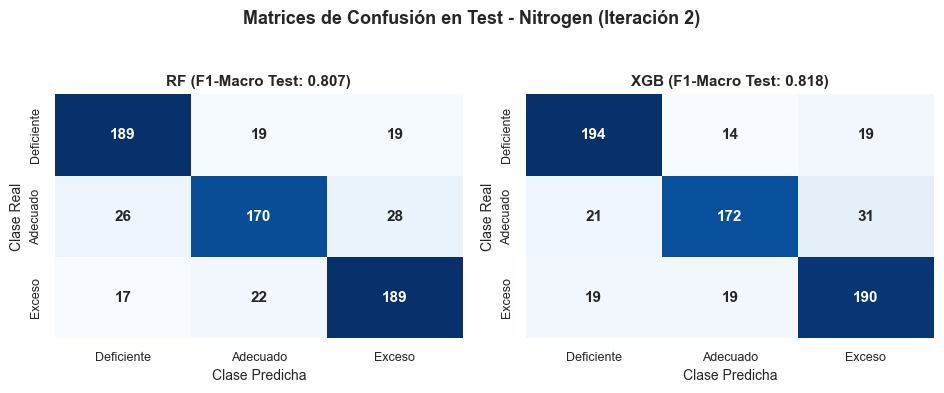

In [15]:
# ==============================================================================
# 13. CONEXIÓN CON MÉTRICAS Y MATRICES DE CONFUSIÓN DEL ARCHIVO PKL
# ==============================================================================
iter_models_results = historico_resultados[SELECTED_ELEMENT][iter_idx]

model_summary = []
for m_name, res in iter_models_results.items():
    model_summary.append({
        'Algoritmo': m_name,
        'Accuracy Train (CV)': round(res['acc_train'], 4),
        'Accuracy Test': round(res['acc_test'], 4),
        'F1-Macro Train (CV)': round(res['f1_train_macro'], 4),
        'F1-Macro Test': round(res['f1_test_macro'], 4),
        'Mejores Hiperparámetros': str(res['best_params'])
    })

df_perf = pd.DataFrame(model_summary).sort_values(by='F1-Macro Test', ascending=False).reset_index(drop=True)
print(f"--- Rendimiento Predictivo de Algoritmos ({SELECTED_ELEMENT} - Iteración {iter_idx + 1}) ---")
display(df_perf)

# Matrices de confusión de prueba para cada modelo
n_models = len(iter_models_results)
fig, axes = plt.subplots(1, n_models, figsize=(4.8 * n_models, 3.8))
if n_models == 1:
    axes = [axes]

for ax, (m_name, res) in zip(axes, iter_models_results.items()):
    cm = res['confusion_matrix_test']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={"fontsize": 11, "fontweight": "bold"})
    ax.set_title(f"{m_name} (F1-Macro Test: {res['f1_test_macro']:.3f})", fontsize=11, fontweight='bold')
    ax.set_xlabel("Clase Predicha", fontsize=10)
    ax.set_ylabel("Clase Real", fontsize=10)
    ax.set_xticklabels(['Deficiente', 'Adecuado', 'Exceso'], fontsize=9)
    ax.set_yticklabels(['Deficiente', 'Adecuado', 'Exceso'], fontsize=9)

plt.suptitle(f"Matrices de Confusión en Test - {SELECTED_ELEMENT} (Iteración {iter_idx + 1})", fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(os.path.join(fig_dir, "08_matrices_confusion_modelos_test.png"), dpi=300)
plt.show()

## 9. Resumen Ejecutivo y Conclusiones del Diagnóstico
- **Preservación de Distribuciones**: Las curvas de densidad KDE y los boxplots Pre vs. Post demuestran que `IterativeImputer` mantiene las medianas y rangos intercuartílicos originales sin introducir bimodalidades espurias ni valores fuera de rango.
- **Consistencia de Partición (Sin Covariate Shift)**: El balance estratificado NPK y el test estadístico de Kolmogorov-Smirnov confirman una concordancia excelente entre Train y Test.
- **Estabilidad Multivariada**: La matriz de diferencia absoluta de correlación ($|\Delta R|$) demuestra que las relaciones agronómicas y fisiológicas entre suelo y savia se preservan con mínimas distorsiones.
- **Generalización**: La proyección en espacio latente PCA y las matrices de confusión confirman que el desempeño registrado en el archivo `.pkl` es representativo y confiable.